In [1]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

from mean_shift import mean_shift, deduplicate

In [2]:
import matplotlib as mpl

# Global settings for publication-quality plots
mpl.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "stix",
    "font.size": 9,          # Base font size
    "axes.titlesize": 10,    # Title font size
    "axes.labelsize": 9,     # X/Y label font size
    "xtick.labelsize": 8,    # Tick label font size
    "ytick.labelsize": 8,
    "legend.fontsize": 8,    # Legend font size

    # Line styles
    "lines.linewidth": 1.2,
    "lines.markersize": 4,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "figure.figsize": (3.3, 2.5),  # ~1-column figure in most journals
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

In [3]:
data = np.load("muller_brown_GADES_1e6_clamped.npy")

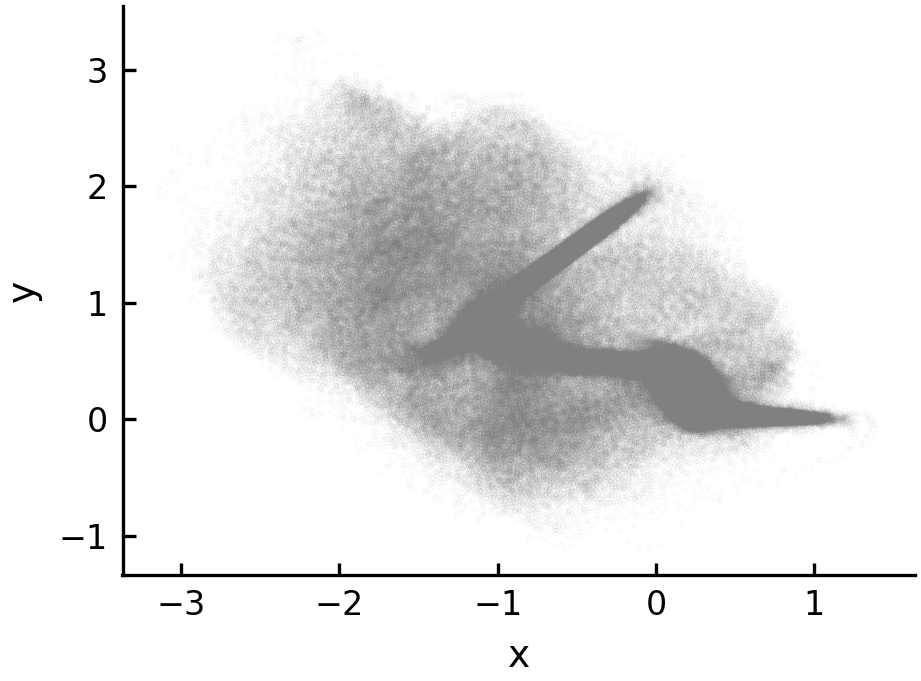

In [ ]:
# Plot
fig, ax = plt.subplots()

# Original data as scatter
ax.scatter(data[:, 0], data[:, 1], s=0.01, alpha=0.1, c='gray', label='Original data')

ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [4]:
# Fit KDE to the point cloud
kde = gaussian_kde(data.T)  # gaussian_kde expects shape (d, n)

In [6]:
# Run mean shift from all data points (or a subsample for speed)
n_starts = min(len(data), 500)
idx = np.random.choice(len(data), n_starts, replace=False)
start_points = data[idx]

modes = mean_shift(start_points, kde, min_density=0.5)

maxima = deduplicate(modes)
print(f"Found {len(maxima)} local maxima of the density estimate:")
print(maxima)

Mean shift:   0%|          | 0/300 [00:00<?, ?it/s]

Found 3 local maxima of the density estimate:
[[ 0.18222     0.34733177]
 [ 0.53938405  0.0364264 ]
 [-0.56762427  1.43228364]]


In [5]:
maxima= np.asarray([
    [-0.56762427,  1.43228364],
    [ 0.53938401,  0.03642641],
    [ 0.18218053,  0.34740155],
 ])

In [6]:
# Create a grid for KDE contour plot
x_min, x_max = data[:, 0].min() - 0.5, data[:, 0].max() + 0.5
y_min, y_max = data[:, 1].min() - 0.5, data[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
grid_points = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_points).reshape(xx.shape)

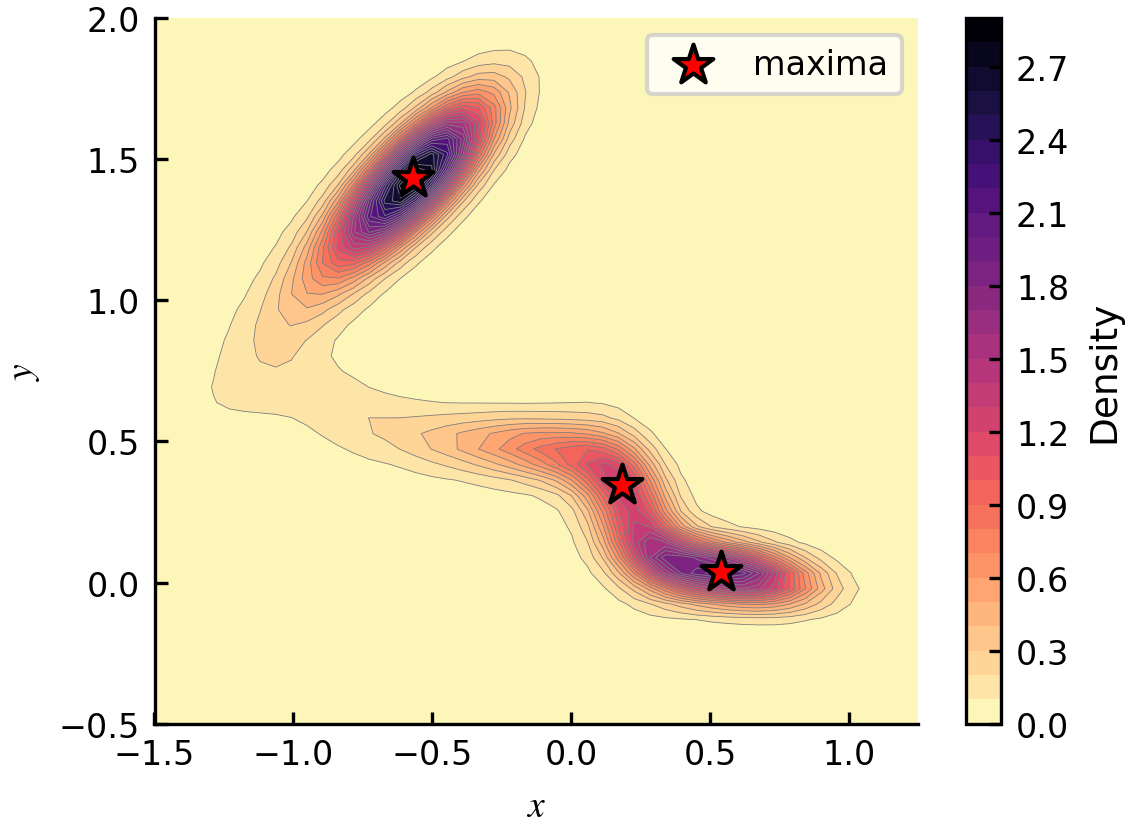

In [ ]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)

# KDE as filled contour
contour = ax.contourf(xx, yy, zz, levels=30, cmap='magma_r', alpha=1.0)
plt.colorbar(contour, ax=ax, label='Density')

# KDE contour lines
ax.contour(xx, yy, zz, levels=30, colors='gray', linewidths=0.2, alpha=1.0)

# Found maxima (density peaks)
ax.scatter(maxima[:, 0], maxima[:, 1], s=100, c='red', marker='*', 
           edgecolors='black', linewidths=1, label=f'maxima', zorder=10)

ax.set_xlim([-1.5, 1.25])
ax.set_ylim([-0.5, 2.0])
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

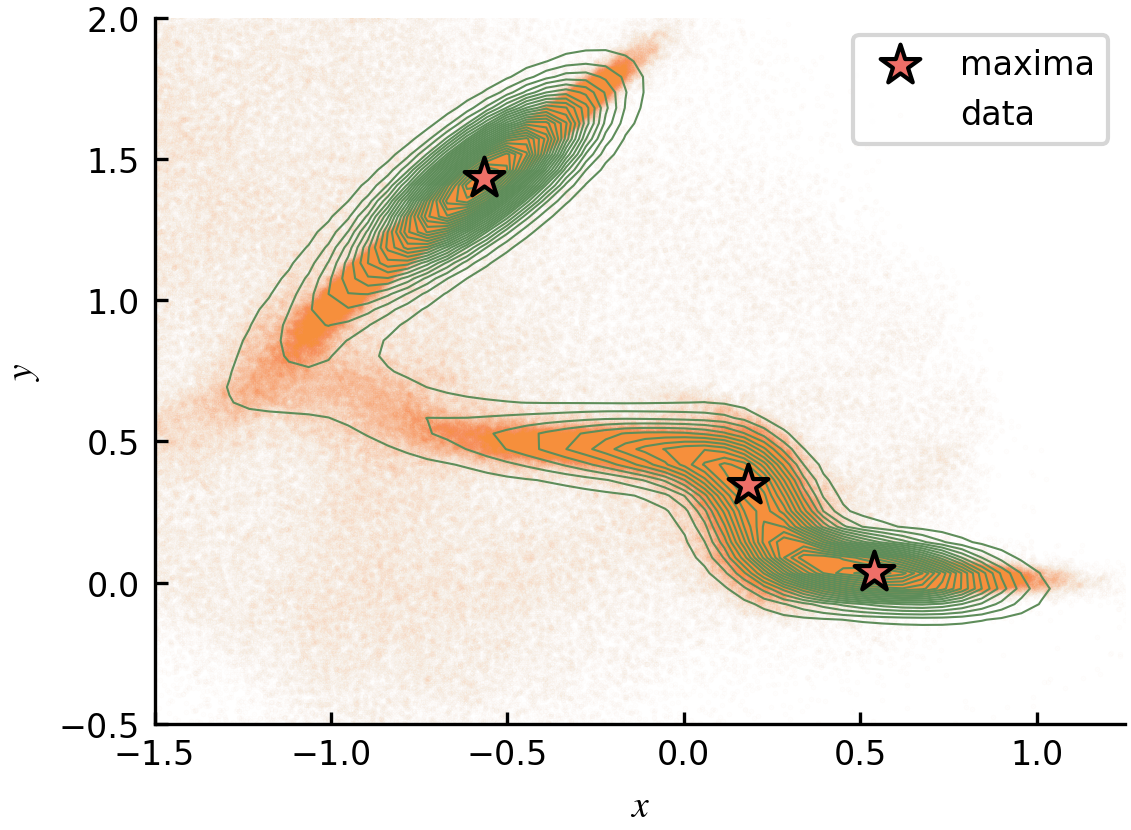

In [ ]:
# Plot
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)

# KDE contour lines
ax.contour(xx, yy, zz, levels=30, colors='#5e8d5a', linewidths=0.5, alpha=1.0)

# Found maxima (density peaks)
ax.scatter(maxima[:, 0], maxima[:, 1], s=100, c='#ee6f68', marker='*', 
           edgecolors='black', linewidths=1, label=f'maxima', zorder=10)

# data points
ax.scatter(data[:, 0], data[:, 1], s=0.1, c='#f68f3c', alpha=0.02,
           label='data', zorder=1)

ax.set_xlim([-1.5, 1.25])
ax.set_ylim([-0.5, 2.0])
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig("raw_data_kde_contour.png", dpi=300)
plt.show()